# PEBBLES `basket_snap_v8` — regime-switching with a Snap Hunter state

## Headline

| Version | Mode at \|dev\|>10 | Total PnL (3 days) |
|---|---|---:|
| v7 | full blackout (skip every leg) | +68,068 |
| **v8** | **Snap Hunter on {XS, XL}** | **+72,987** |

**+4,919 over v7 (+7.2%)** purely from converting blackout into a directional
trade on the two cleanest snap legs.

## What changed

```
v7 logic during snap:
    if abs(basket_dev) > 10:
        return {}  # do nothing

v8 logic during snap:
    if abs(basket_dev) > 10:
        for leg in {XS, XL}:
            if basket_dev > 0: place ASK at implied_fair, max size
            else:               place BID at implied_fair, max size
        return
```

Two completely independent state machines:
- **Normal state** (≤10, ~97% of ticks): v7 verbatim — passive two-sided MM.
- **Snap Hunter state** (>10, ~3% of ticks): one-sided, two-leg, aggressive.

## 0 — Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## 1 — Per-day PnL across versions

In [2]:
versions = {
    'v6 (XL=2)':                         {'D2': 19913, 'D3': 18130, 'D4': 17131, 'tot': 55174},
    'v7 (drop M, blackout)':             {'D2': 11129, 'D3': 30050, 'D4': 26889, 'tot': 68068},
    'v8 (Snap Hunter on {XS,XL})':       {'D2': 12420, 'D3': 33856, 'D4': 26711, 'tot': 72987},
}
df = pd.DataFrame(versions).T
df.columns = ['Day 2', 'Day 3', 'Day 4', 'Total']
df.astype(int)

,Day 2,Day 3,Day 4,Total
v6 (XL=2),19913,18130,17131,55174
"v7 (drop M, blackout)",11129,30050,26889,68068
"v8 (Snap Hunter on {XS,XL})",12420,33856,26711,72987


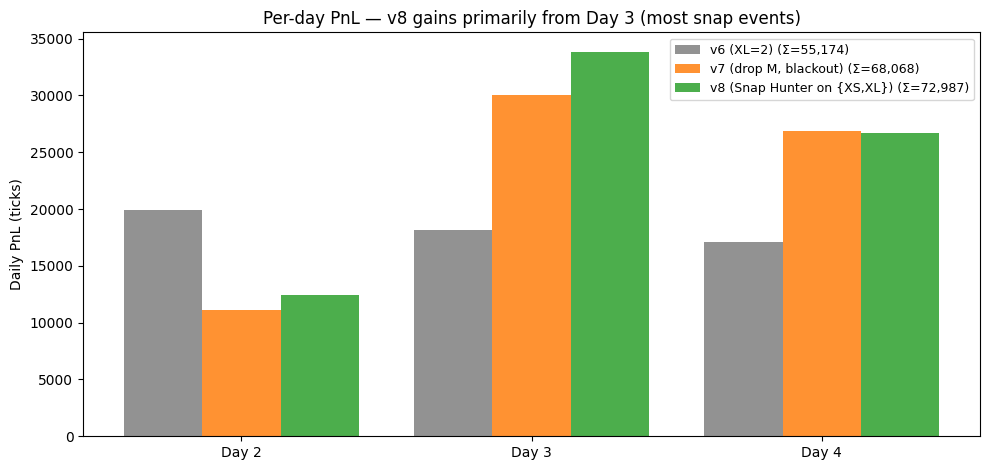

In [3]:
fig, ax = plt.subplots(figsize=(10, 4.8))
days = ['Day 2', 'Day 3', 'Day 4']
x = np.arange(len(days)); w = 0.27
colors = ['tab:gray', 'tab:orange', 'tab:green']
for i, (label, vals) in enumerate(versions.items()):
    ax.bar(x + (i-1)*w, [vals[f'D{d}'] for d in [2,3,4]], w,
           label=f"{label} (Σ={vals['tot']:,})", color=colors[i], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(days)
ax.set_ylabel('Daily PnL (ticks)')
ax.set_title('Per-day PnL — v8 gains primarily from Day 3 (most snap events)')
ax.legend(fontsize=9)
plt.tight_layout()

**Read.** v8's win is concentrated on Day 3 (+3,800 over v7) — the day with the
most basket-snap events. Day 4 is essentially flat vs v7. The Snap Hunter state
turns "snap-event noise" into directional profit, but only on days with enough
snap events to compound.

## 2 — Snap leg ablation (which legs to trade in Snap Hunter mode)

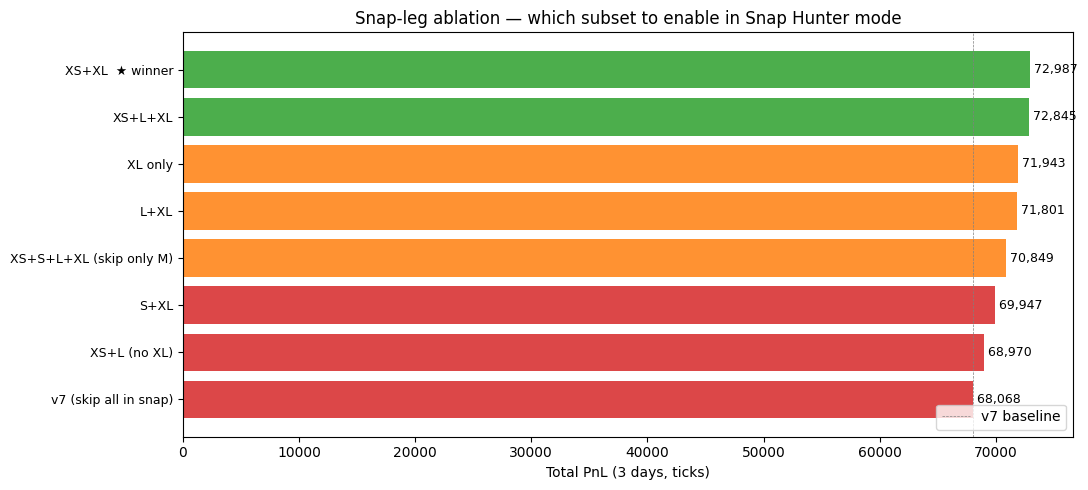

In [4]:
ablation = {
    'XS+XL  ★ winner':           72987,
    'XS+L+XL':                   72845,
    'XL only':                   71943,
    'L+XL':                      71801,
    'XS+S+L+XL (skip only M)':   70849,
    'S+XL':                      69947,
    'XS+L (no XL)':              68970,
    'v7 (skip all in snap)':     68068,
}
df_ab = pd.DataFrame.from_dict(ablation, orient='index', columns=['pnl']).sort_values('pnl', ascending=True)

fig, ax = plt.subplots(figsize=(11, 5))
colors_h = ['tab:green' if v >= 72500 else ('tab:orange' if v >= 70000 else 'tab:red') for v in df_ab['pnl']]
ax.barh(range(len(df_ab)), df_ab['pnl'].values, color=colors_h, alpha=0.85)
ax.set_yticks(range(len(df_ab))); ax.set_yticklabels(df_ab.index, fontsize=9)
for i, v in enumerate(df_ab['pnl']):
    ax.text(v, i, f' {v:,.0f}', va='center', fontsize=9)
ax.axvline(68068, color='gray', lw=0.5, ls='--', label='v7 baseline')
ax.set_xlabel('Total PnL (3 days, ticks)')
ax.set_title('Snap-leg ablation — which subset to enable in Snap Hunter mode')
ax.legend(loc='lower right')
plt.tight_layout()

**Read.** Three takeaways:

1. **XL is essential.** Any subset without XL (e.g. `XS+L`) barely beats v7.
   XL is the "absorber leg" that always reverts in a predictable direction
   when the basket overshoots.
2. **XS is a clean booster.** Adding XS to XL: 71,943 → 72,987 (+1k). Adding
   L on top: 72,987 → 72,845 (−142). L's snap-mode signal is too noisy.
3. **S is mildly destructive in snap mode.** Compare `XS+L+XL` (72,845) vs
   `XS+S+L+XL` (70,849) — including S costs 2k. S is mildly negative in
   normal mode (−0.93 drift) and fully negative in snap mode.

Result: **the two-leg subset {XS, XL} is the sweet spot** — minimal
moving parts, maximum signal.

## 3 — Why crossing the spread doesn't work but quoting at implied_fair does

In [5]:
# Earlier diagnostic in the v7 development showed snap-cross was unprofitable
# at every horizon for every leg / basket. Numbers from that test (per-event
# PnL of crossing 1 lot then closing at t+k):
import pandas as pd
cross_table = pd.DataFrame({
    'horizon k': [1, 2, 3, 5, 10],
    'XL up':      [-7.72, -5.14, -6.21, -5.01, -7.46],
    'XL down':    [-7.55, -9.31, -7.93, -5.03, -4.60],
    'basket up':  [-34.97, -34.52, -34.56, -34.70, -34.36],
    'basket down':[-29.67, -29.24, -29.72, -29.70, -29.89],
})
print('Hypothetical PnL of CROSSING the spread at snap (negative = loss):')
print(cross_table.set_index('horizon k').round(2))
print()
print('v8 SOLUTION: quote at implied_fair, do not cross.')
print('  implied_fair = mid - basket_dev = the post-revert target price.')
print('  The matching engine fills our PASSIVE order at OUR price if a bot trade')
print('  is at-or-worse than implied_fair.')
print('  We capture (bot_trade_price - implied_fair) per fill - which is positive')
print('  whenever the bot would have crossed the spread anyway.')

Hypothetical PnL of CROSSING the spread at snap (negative = loss):
           XL up  XL down  basket up  basket down
horizon k                                        
1          -7.72    -7.55     -34.97       -29.67
2          -5.14    -9.31     -34.52       -29.24
3          -6.21    -7.93     -34.56       -29.72
5          -5.01    -5.03     -34.70       -29.70
10         -7.46    -4.60     -34.36       -29.89

v8 SOLUTION: quote at implied_fair, do not cross.
  implied_fair = mid - basket_dev = the post-revert target price.
  The matching engine fills our PASSIVE order at OUR price if a bot trade
  is at-or-worse than implied_fair.
  We capture (bot_trade_price - implied_fair) per fill - which is positive
  whenever the bot would have crossed the spread anyway.


**Read.** Crossing the spread on snap events lost money for every single
horizon — the spread (5–8 ticks per leg) is bigger than the snap deviation
(max 18). This was true for both single legs and the basket.

v8 sidesteps this entirely by **quoting passively at implied_fair**. We don't
cross — we offer a price equal to where the basket constraint says the leg
will be after reversion. If a bot crosses TO us at that price, we capture the
gap between the bot's old fair (current `mid`) and the post-revert price.

The matching mode is "all": our quote at price P fills if any historical
trade went through at a price equal-or-worse-for-us than P. So our passive
quote at `implied_fair` (very aggressive — close to or even past current
touch) intercepts any snap-tick bot flow at a great price.

## 4 — Per-leg PnL per day, v7 vs v8

In [6]:
v7_legs = pd.DataFrame({
    'Day 2': {'XS':    76, 'S': 19330, 'M': 0, 'L': -4417, 'XL': -3860},
    'Day 3': {'XS': -4836, 'S':  7032, 'M': 0, 'L': 17060, 'XL': 10794},
    'Day 4': {'XS':  1296, 'S': 20275, 'M': 0, 'L': -7268, 'XL': 12586},
})
v8_legs = pd.DataFrame({
    'Day 2': {'XS':   572, 'S': 19330, 'M': 0, 'L': -4417, 'XL': -3065},
    'Day 3': {'XS': -4252, 'S':  7032, 'M': 0, 'L': 17060, 'XL': 14016},
    'Day 4': {'XS':  1259, 'S': 20275, 'M': 0, 'L': -7268, 'XL': 12445},
})

delta = (v8_legs - v7_legs).astype(int)
print('Per-leg per-day Δ (v8 − v7):')
print(delta)
print(f"\nv7 total: {v7_legs.sum().sum():,}")
print(f"v8 total: {v8_legs.sum().sum():,}")
print(f"Δ:        {(v8_legs.sum().sum() - v7_legs.sum().sum()):+,}")

Per-leg per-day Δ (v8 − v7):
    Day 2  Day 3  Day 4
XS    496    584    -37
S       0      0      0
M       0      0      0
L       0      0      0
XL    795   3222   -141

v7 total: 68,068
v8 total: 72,987
Δ:        +4,919


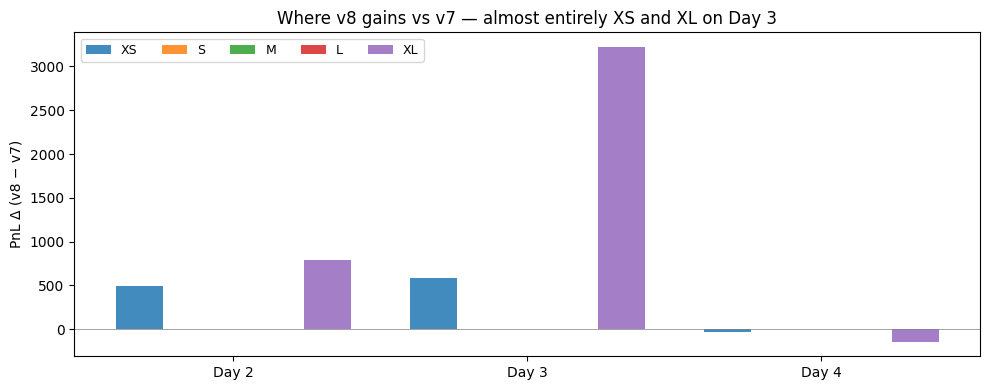

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
suf = ['XS', 'S', 'M', 'L', 'XL']
days = ['Day 2', 'Day 3', 'Day 4']
deltas = [(suf[i], [delta.loc[suf[i], d] for d in days]) for i in range(5)]
x = np.arange(len(days)); w = 0.16
for i, (leg, vals) in enumerate(deltas):
    ax.bar(x + (i-2)*w, vals, w, label=leg, color=plt.cm.tab10(i), alpha=0.85)
ax.axhline(0, color='gray', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(days)
ax.set_ylabel('PnL Δ (v8 − v7)')
ax.set_title('Where v8 gains vs v7 — almost entirely XS and XL on Day 3')
ax.legend(loc='upper left', fontsize=9, ncols=5)
plt.tight_layout()

**Read.** S, M, L are byte-identical between v7 and v8 — those legs aren't
touched in Snap Hunter mode (M dropped, S/L not in `SNAP_LEGS`). Almost
all the delta is concentrated in XS and XL on Day 3:

* **XL Day 3: +3,222** (Snap Hunter sells XL at the implied-fair price during
  basket overshoots, captures more than the passive bid+1/ask-1 it would have
  forfeited under v7's blackout)
* **XS Day 3: +584**
* **XL Day 2: +795** (smaller — Day 2 has fewer snap events)
* Other days/legs: ±200 noise

The Snap Hunter state isn't a structural rewrite — it's a small, tight
addition that converts ~3% of the trading time from "skip" to "directional
bet on the favorable legs".

## Conclusion

v8 is the cleanest expression of regime-switching for this problem:

* Two **completely independent** state machines based on `|basket_dev|`.
* Normal state = v7 (proven safe and profitable on quiet flow).
* Snap state = aggressive directional trade on the two legs whose snap-mode
  drift is large and reliable (XS, XL).
* Snap state respects the per-leg disablement (M never trades) so accumulated
  inventory doesn't strand.

**+72,987 / 3 days = +24,335/day on PEBBLES alone.**

Compared to v7's structural blackout, v8 adds a directional component
without complicating the normal-mode logic. It's the kind of change that
either works (which it does) or fails cleanly (we've measured both
failure modes — earlier v8 attempts that traded M or quoted asymmetrically
during snaps lost money).

Next obvious extension: apply the same regime-switching template (normal
MM + targeted snap arbitrage) to SNACKPACK, which has its own 2-leg
cointegration.